正在尝试使用 utf-8-sig 读取文件...
utf-8-sig 读取失败，继续尝试其他编码。
正在尝试使用 utf-8 读取文件...
utf-8 读取失败，继续尝试其他编码。
正在尝试使用 gb18030 读取文件...

CSV 文件读取成功！
使用编码：gb18030
数据行数：19861
数据列数：20

原始列名：
['#BioSample', 'Assembly', 'host', 'host_1', 'Location', 'country', 'continent', 'Isolation source', 'SNP cluster', 'Length', 'Virulence genotypes', 'AMR genotypes', 'AST phenotypes', 'Isolation type', 'PFGE primary enzyme pattern', 'BioProject', 'Contigs', 'Collection date', 'year', 'ST']

数据前5行：
     #BioSample         Assembly          host host_1     Location  \
0  SAMN12087643  GCA_006492265.1  Homo sapiens  human  Afghanistan   
1  SAMN12087644  GCA_006492585.1  Homo sapiens  human  Afghanistan   
2  SAMN12087641  GCA_006494155.1  Homo sapiens  human  Afghanistan   
3  SAMN12087640  GCA_006494175.1  Homo sapiens  human  Afghanistan   
4  SAMN12087642  GCA_006658565.1  Homo sapiens  human  Afghanistan   

       country continent Isolation source      SNP cluster   Length  \
0  Afghanistan      Asia      respiratory 

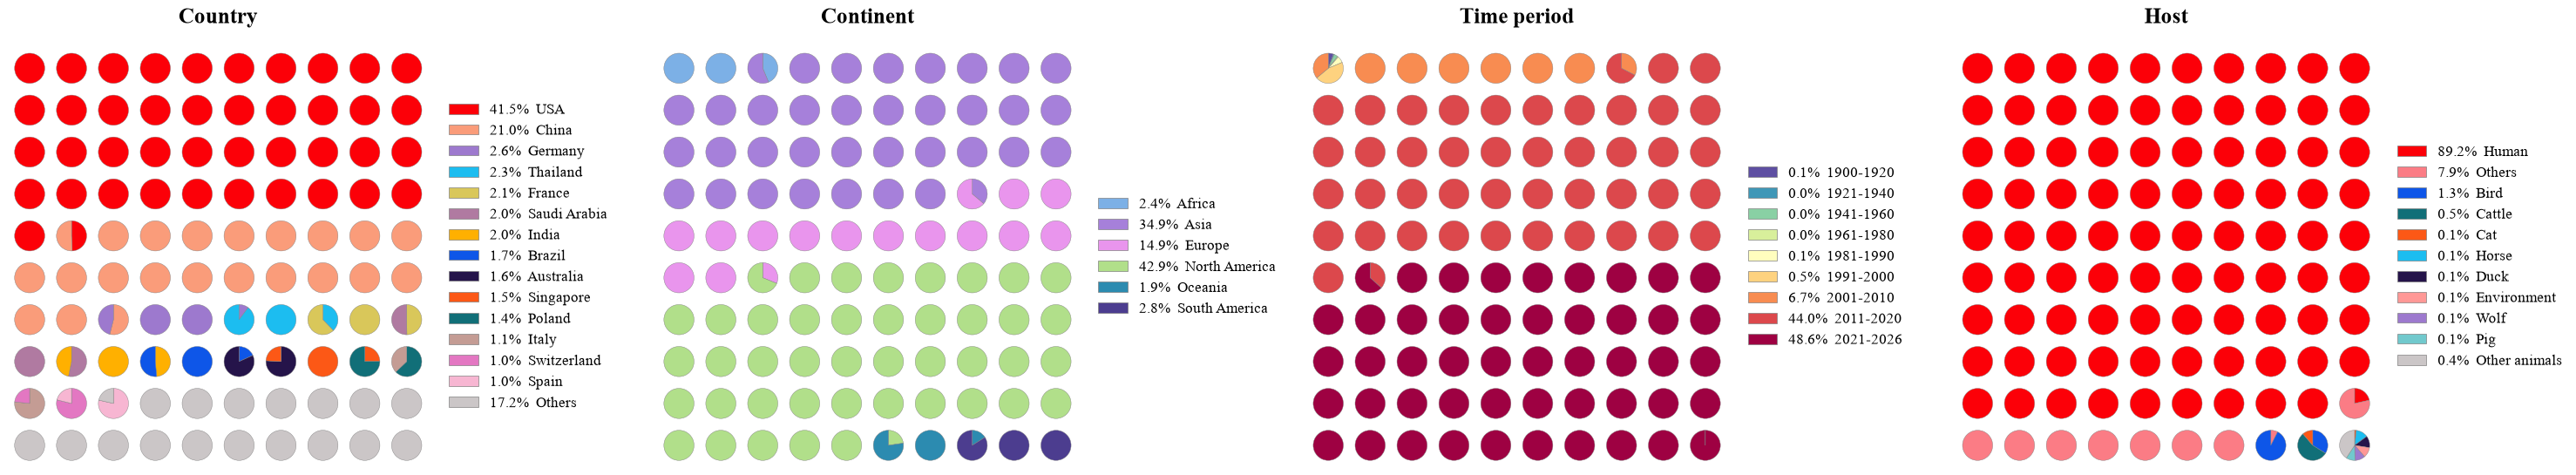


华夫饼图绘制完成！
CSV编码：gb18030
原始数据量：19861
图片保存路径：D:\python\敏感性分析\华夫饼图_1行4图.png
图片布局：1行 × 4列
图片分辨率：600 DPI


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge, Patch
import matplotlib


# ============================================================
# 0. 基础设置
# ============================================================

# 全局字体设置为 Times New Roman
matplotlib.rcParams['font.family'] = 'Times New Roman'

# 防止负号显示异常
matplotlib.rcParams['axes.unicode_minus'] = False


# ============================================================
# 1. 绘制连续型华夫饼图函数
# ============================================================

def draw_continuous_waffle(ax, category_percentages, title, colors=None):
    """
    在指定 Axes 上绘制连续型华夫饼图（10 × 10圆圈）。

    每一个圆圈代表 1%。
    如果某一个类别的百分比不是整数，
    最后一个圆圈会按照比例被多个类别分割。
    """

    # 删除 NaN
    category_percentages = category_percentages.dropna()

    # 防止没有数据
    if len(category_percentages) == 0:
        ax.axis('off')
        ax.set_title(title, pad=20, fontsize=18, fontweight='bold')
        return

    # 如果总和为0，不绘制
    if category_percentages.sum() == 0:
        ax.axis('off')
        ax.set_title(title, pad=20, fontsize=18, fontweight='bold')
        return

    # 强制标准化为100%
    category_percentages = (
        category_percentages
        / category_percentages.sum()
        * 100
    )

    # --------------------------------------------------------
    # 如果没有指定颜色，则自动生成
    # --------------------------------------------------------
    if colors is None:
        cmap = plt.get_cmap('tab20')

        colors = {
            cat: cmap(i % 20)
            for i, cat in enumerate(category_percentages.index)
        }

    # --------------------------------------------------------
    # 创建100个圆圈
    # 每个圆圈容量 = 1%
    # --------------------------------------------------------
    circles = [{} for _ in range(100)]

    circle_idx = 0
    current_capacity = 1.0

    # --------------------------------------------------------
    # 将各类别比例依次分配到100个圆圈
    # --------------------------------------------------------
    for cat, p in category_percentages.items():

        remaining_p = float(p)

        while remaining_p > 1e-10 and circle_idx < 100:

            alloc = min(remaining_p, current_capacity)

            if cat not in circles[circle_idx]:
                circles[circle_idx][cat] = 0

            circles[circle_idx][cat] += alloc

            remaining_p -= alloc
            current_capacity -= alloc

            # 当前圆圈已经填满
            if current_capacity < 1e-10:
                circle_idx += 1
                current_capacity = 1.0

    # --------------------------------------------------------
    # 设置坐标轴
    # --------------------------------------------------------
    ax.set_aspect('equal')

    ax.set_xlim(-0.5, 9.5)
    ax.set_ylim(-0.5, 9.5)

    ax.axis('off')

    # --------------------------------------------------------
    # 绘制100个圆圈
    # --------------------------------------------------------
    for i, circle_data in enumerate(circles):

        if not circle_data:
            continue

        # 10列 × 10行
        row = 9 - (i // 10)
        col = i % 10

        # 从顶部开始
        current_theta = 90

        for cat, size in circle_data.items():

            theta2_wedge = current_theta
            current_theta -= size * 360
            theta1_wedge = current_theta

            wedge = Wedge(
                center=(col, row),
                r=0.36,
                theta1=theta1_wedge,
                theta2=theta2_wedge,
                facecolor=colors.get(cat, '#CCCCCC'),
                edgecolor='grey',
                linewidth=0.3
            )

            ax.add_patch(wedge)

    # --------------------------------------------------------
    # 标题
    # --------------------------------------------------------
    ax.set_title(
        title,
        pad=20,
        fontsize=18,
        fontweight='bold'
    )

    # --------------------------------------------------------
    # 图例
    # --------------------------------------------------------
    legend_elements = []

    for cat, p in category_percentages.items():

        legend_elements.append(
            Patch(
                facecolor=colors.get(cat, '#CCCCCC'),
                edgecolor='grey',
                linewidth=0.5,
                label=f"{p:.1f}%  {cat}"
            )
        )

    ax.legend(
        handles=legend_elements,
        loc='center left',
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
        fontsize=12
    )


# ============================================================
# 2. 文件路径
# ============================================================

file_path = (r'D:\A.baumannii\data\metadata.csv')

output_path = (
    'waffle_chart.png'
)


# ============================================================
# 3. 自动读取 CSV
#    解决 UnicodeDecodeError
# ============================================================

# 常见编码依次尝试
encodings = [
    'utf-8-sig',
    'utf-8',
    'gb18030',
    'gbk',
    'cp936'
]

df = None
successful_encoding = None


if not os.path.exists(file_path):
    raise FileNotFoundError(
        f"\n找不到文件：\n{file_path}\n"
        "请检查文件路径是否正确。"
    )


for encoding in encodings:

    try:

        print(f"正在尝试使用 {encoding} 读取文件...")

        df = pd.read_csv(
            file_path,
            encoding=encoding
        )

        successful_encoding = encoding

        print("\n====================================")
        print("CSV 文件读取成功！")
        print(f"使用编码：{encoding}")
        print(f"数据行数：{df.shape[0]}")
        print(f"数据列数：{df.shape[1]}")
        print("====================================\n")

        break

    except UnicodeDecodeError:

        print(f"{encoding} 读取失败，继续尝试其他编码。")


# 所有编码都失败
if df is None:

    raise UnicodeDecodeError(
        "unknown",
        b"",
        0,
        1,
        "常见编码均无法读取该 CSV，请检查文件实际编码。"
    )


# ============================================================
# 4. 检查数据列
# ============================================================

print("原始列名：")
print(df.columns.tolist())
print()


# 去除列名前后的空格
df.columns = df.columns.astype(str).str.strip()


required_columns = [
    'continent',
    'year',
    'host_1',
    'country'
]


missing_columns = [
    col
    for col in required_columns
    if col not in df.columns
]


if missing_columns:

    raise ValueError(
        "\n数据中缺少以下必要列：\n"
        + str(missing_columns)
        + "\n\n当前实际列名为：\n"
        + str(df.columns.tolist())
    )


# ============================================================
# 5. 基础数据清洗
# ============================================================

# ------------------------------------------------------------
# continent
# ------------------------------------------------------------

df['continent'] = (
    df['continent']
    .astype('string')
    .str.strip()
)


# ------------------------------------------------------------
# country
# ------------------------------------------------------------

df['country'] = (
    df['country']
    .astype('string')
    .str.strip()
)


# ------------------------------------------------------------
# host
# ------------------------------------------------------------

df['host_1'] = (
    df['host_1']
    .astype('string')
    .str.strip()
)


# ------------------------------------------------------------
# year
# 转为数字，无法识别的值变成 NaN
# ------------------------------------------------------------

df['year'] = pd.to_numeric(
    df['year'],
    errors='coerce'
)


print("数据前5行：")
print(df.head())
print()


# ============================================================
# 6. 大洲数据
# ============================================================

continent_data = (
    df['continent']
    .dropna()
)


continent_pct = (
    continent_data
    .value_counts(normalize=True)
    .sort_index()
    * 100
)


print("---------- Continent ----------")
print(continent_pct)
print()


# ============================================================
# 7. 时间数据
# ============================================================

bins = [
    1899,
    1920,
    1940,
    1960,
    1980,
    1990,
    2000,
    2010,
    2020,
    2026
]


labels = [
    "1900-1920",
    "1921-1940",
    "1941-1960",
    "1961-1980",
    "1981-1990",
    "1991-2000",
    "2001-2010",
    "2011-2020",
    "2021-2026"
]


# 创建时间分组
df['Time period'] = pd.cut(
    df['year'],
    bins=bins,
    labels=labels,
    include_lowest=True
)


# 注意：
# normalize=True 时默认不会计算 NaN
time_pct = (
    df['Time period']
    .value_counts(normalize=True)
    .reindex(labels)
    .fillna(0)
    * 100
)


print("---------- Time period ----------")
print(time_pct)
print()


# ============================================================
# 8. 宿主数据
#    Top 10 + Other animals
# ============================================================

host_original = (
    df['host_1']
    .dropna()
)


# 原始宿主比例
host_counts = (
    host_original
    .value_counts(normalize=True)
    * 100
)


# 获取出现频率最高的10种宿主
top_hosts = (
    host_counts
    .head(10)
    .index
    .tolist()
)


# 创建临时变量，避免修改原始数据
df_temp = df.copy()


# Top10 保留，其余归入 Other animals
df_temp['host_group'] = df_temp['host_1'].apply(
    lambda x:
    str(x).strip().capitalize()
    if pd.notna(x) and x in top_hosts
    else 'Other animals'
)


# 计算比例
host_pct = (
    df_temp['host_group']
    .value_counts(normalize=True)
    * 100
)


# 将 Other animals 始终放在最后
if 'Other animals' in host_pct.index:

    others_val = host_pct.loc['Other animals']

    host_pct = host_pct.drop(
        index='Other animals'
    )

    host_pct = host_pct.sort_values(
        ascending=False
    )

    host_pct.loc['Other animals'] = others_val

else:

    host_pct = host_pct.sort_values(
        ascending=False
    )


print("---------- Host ----------")
print(host_pct)
print()


# ============================================================
# 9. 国家数据
#    Top 14 + Others
# ============================================================

country_original = (
    df['country']
    .dropna()
)


country_counts = (
    country_original
    .value_counts(normalize=True)
    * 100
)


top_countries = (
    country_counts
    .head(14)
    .index
    .tolist()
)


# 新建 country_group
# 不直接覆盖原始 country
df['country_group'] = df['country'].apply(
    lambda x:
    x
    if pd.notna(x) and x in top_countries
    else 'Others'
)


country_pct = (
    df['country_group']
    .value_counts(normalize=True)
    * 100
)


# 将 Others 放在最后
if 'Others' in country_pct.index:

    others_country = country_pct.loc['Others']

    country_pct = country_pct.drop(
        index='Others'
    )

    country_pct = country_pct.sort_values(
        ascending=False
    )

    country_pct.loc['Others'] = others_country

else:

    country_pct = country_pct.sort_values(
        ascending=False
    )


print("---------- Country ----------")
print(country_pct)
print()


# ============================================================
# 10. 颜色映射
# ============================================================

# ------------------------------------------------------------
# Continent
# ------------------------------------------------------------

colors_continent = {
    'Africa': '#7CB0E6',
    'Asia': '#A680DA',
    'Europe': '#E995ED',
    'North America': '#B1DF8A',
    'Oceania': '#2C8BB0',
    'South America': '#4C3D8F'
}


# ------------------------------------------------------------
# Host
# ------------------------------------------------------------

colors_host = {
    'Duck': '#25144A',
    'Other animals': '#CBC6C7',
    'Bird': '#0E56E8',
    'Cattle': '#116F78',
    'Cat': '#FC5816',
    'Human': '#FC0008',
    'Wolf': '#9D79CE',
    'Horse': '#1CBDF0',
    'Pig': '#71C9CD',
    'Earthworm': '#FA9C7A',
    'Others': '#FB7C85'
}


# ------------------------------------------------------------
# Country
# ------------------------------------------------------------

colors_country = {
    'Australia': '#25144A',
    'Others': '#CBC6C7',
    'Brazil': '#0E56E8',
    'Poland': '#116F78',
    'Singapore': '#FC5816',
    'USA': '#FC0008',
    'Germany': '#9D79CE',
    'Thailand': '#1CBDF0',
    'Viet Nam': '#71C9CD',
    'China': '#FA9C7A',
    'South Africa': '#FB7C85',
    'France': '#D9C75A',
    'Saudi Arabia': '#B07AA1',
    'Hungary': '#9AD18B',
    'India': '#FFB000'
}


# ------------------------------------------------------------
# Time period
# ------------------------------------------------------------

cmap_time = plt.get_cmap('Spectral_r')


colors_time = {
    label: cmap_time(
        i / max(len(labels) - 1, 1)
    )
    for i, label in enumerate(labels)
}


# ============================================================
# 11. 对颜色表中没有定义的类别自动补色
# ============================================================

automatic_cmap = plt.get_cmap('tab20')


# Country
for i, cat in enumerate(country_pct.index):

    if cat not in colors_country:

        colors_country[cat] = automatic_cmap(
            i % 20
        )


# Host
for i, cat in enumerate(host_pct.index):

    if cat not in colors_host:

        colors_host[cat] = automatic_cmap(
            i % 20
        )


# Continent
for i, cat in enumerate(continent_pct.index):

    if cat not in colors_continent:

        colors_continent[cat] = automatic_cmap(
            i % 20
        )


# ============================================================
# 12. 绘制 1行4列 华夫饼图
# ============================================================

fig, axes = plt.subplots(
    1,
    4,
    figsize=(28, 6)
)


# 图1 Country
draw_continuous_waffle(
    axes[0],
    country_pct,
    "Country",
    colors_country
)


# 图2 Continent
draw_continuous_waffle(
    axes[1],
    continent_pct,
    "Continent",
    colors_continent
)


# 图3 Time period
draw_continuous_waffle(
    axes[2],
    time_pct,
    "Time period",
    colors_time
)


# 图4 Host
draw_continuous_waffle(
    axes[3],
    host_pct,
    "Host",
    colors_host
)


# ============================================================
# 13. 调整图间距
# ============================================================

plt.subplots_adjust(
    left=0.01,
    right=0.98,
    bottom=0.05,
    top=0.90,
    wspace=0.55
)


# ============================================================
# 14. 保存高清图片
# ============================================================

# 如果目录不存在则自动创建
output_dir = os.path.dirname(output_path)

if output_dir:
    os.makedirs(
        output_dir,
        exist_ok=True
    )


plt.savefig(
    output_path,
    dpi=600,
    bbox_inches='tight',
    facecolor='white'
)


# 显示
plt.show()


# ============================================================
# 15. 最终提示
# ============================================================

print("\n========================================")
print("华夫饼图绘制完成！")
print("========================================")
print(f"CSV编码：{successful_encoding}")
print(f"原始数据量：{len(df)}")
print(f"图片保存路径：{output_path}")
print("图片布局：1行 × 4列")
print("图片分辨率：600 DPI")
print("========================================")
